# Modelo Multimodal: MTDE-Net (Baseline vs. Optimizado)

Este cuaderno implementa de manera secuencial el entrenamiento y comparación de **MTDE-Net**:
1. **Fase A (Baseline):** Entrenamiento con la configuración inicial por defecto (sin sintonizar).
2. **Fase B (Optimizado):** Entrenamiento con la configuración de hiperparámetros campeona encontrada mediante optimización bayesiana con Optuna y semilla fija.

Al final del cuaderno, se genera de manera automática una **tabla comparativa de métricas** lista para incluir en el reporte final de tu tesis.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

from src.models.mtde_net import MTDE_Net
from src.loaders.mtde_net_loader import MultimodalThermalDataset
from src.utils import SqrtScaledMSELoss, eval_mtde_net_metrics, build_subject_split_plan, subject_summary, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 2. Carga del Dataset y Partición Estricta (Compartida)

In [ ]:
dev = "cuda" if torch.cuda.is_available() else "cpu"
time_scale = 30.0

train_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=True, 
    min_time_s=0.0,
    time_scale=time_scale
)
val_ds_full = MultimodalThermalDataset(
    metadata_csv="../processed_data/metadata_train.csv", 
    is_train=False, 
    min_time_s=0.0,
    time_scale=time_scale
)

# Forzar el mapeo de ruta para entorno notebook
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

df = train_ds_full.df

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=6,
    seed=42,
    # test_subjects=["tania"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects} ({len(f.train_indices)} muestras), Val subjects {f.val_subjects} ({len(f.val_indices)} muestras)")

Resumen de sujetos en metadata:
        name  n_sequences  n_samples      surface  gender  is_complete
0     alonso            3        141        glass    male        False
1     angelo            6        281  glass, wood    male         True
2    eduardo            1         47         wood    male        False
3    esteban            6        276  glass, wood    male         True
4   fabricio            6        278  glass, wood    male         True
5    johamin            2         93         wood    male        False
6  juandiego            6        280  glass, wood    male         True
7     matias            6        282  glass, wood    male         True
8     renato            3        141         wood    male        False
9      tania            6        278  glass, wood  female         True

Plan de partición:
Sujetos de Test (5): ['alonso', 'eduardo', 'johamin', 'renato', 'tania'] (Muestras: 700)
Sujetos de Train/Val (5): ['angelo', 'esteban', 'fabricio', 'juandiego', 'mati

--- 
## FASE A: Entrenamiento del Modelo Baseline (Sin Tunear)

Esta sección entrena el modelo con los hiperparámetros iniciales por defecto.

In [4]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,
    "weight_decay": 0.0005,
}

set_seed(42)

fold_metrics_base = []
histories_base = []

print("=" * 60)
print("FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(val_ds_full, fold.val_indices), batch_size=BASELINE_CONFIG["batch_size"])
    train_eval_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=BASELINE_CONFIG["batch_size"])
    
    model = MTDE_Net(dropout=0.2).to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, BASELINE_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_img, x_tab, y in train_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_img, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_img.size(0)
            n += x_img.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_img, val_x_tab, val_y in val_loader:
                val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_img, val_x_tab), val_y)
                val_loss += loss.item() * val_x_img.size(0)
                val_n += val_x_img.size(0)
        val_loss /= val_n
        
        val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=time_scale)
        train_m = eval_mtde_net_metrics(model, train_eval_loader, dev, scale=time_scale)
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - BASELINE_CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../MTDE_Net_baseline_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= BASELINE_CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_base.append(best_metrics)
    histories_base.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_base = pd.DataFrame(fold_metrics_base)
cv_mean_base = df_folds_base.mean().to_dict()
cv_std_base = df_folds_base.std().to_dict()

print("\n" + "=" * 60)
print("FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)")
print("=" * 60)

trainval_loader = DataLoader(Subset(train_ds_full, plan.trainval_indices), batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(Subset(val_ds_full, plan.test_indices), batch_size=BASELINE_CONFIG["batch_size"])

model_base = MTDE_Net(dropout=0.2).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_base.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

# Para el modelo final, entrenamos hasta el número promedio de épocas óptimas
avg_epochs = int(np.mean([len(h["train_loss"]) - BASELINE_CONFIG["patience"] for h in histories_base]))
avg_epochs = max(10, avg_epochs)
print(f"Entrenando modelo final por {avg_epochs} épocas...")

for ep in range(1, avg_epochs + 1):
    model_base.train()
    train_loss, n = 0.0, 0
    for x_img, x_tab, y in trainval_loader:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_base(x_img, x_tab), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_img.size(0)
        n += x_img.size(0)
    scheduler.step()

torch.save(model_base.state_dict(), "../MTDE_Net_baseline.pt")
baseline_metrics = eval_mtde_net_metrics(model_base, test_loader, dev, scale=time_scale)
print(f"Modelo Baseline Final evaluado en Test Set. MAE: {baseline_metrics['mae']:.2f}s | RMSE: {baseline_metrics['rmse']:.2f}s")

FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 35.06s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 30.23s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 19.21s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 32.08s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 45.18s

FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)
Entrenando modelo final por 31 épocas...
Modelo Baseline Final evaluado en Test Set. MAE: 51.70s | RMSE: 74.43

--- 
## FASE B: Entrenamiento del Modelo Optimizado (Optuna Champion)

Esta sección entrena el modelo con los hiperparámetros óptimos encontrados en tu estudio determinista con Optuna.

In [ ]:
# 1. Hiperparámetros Campeones Encontrados
OPTIMIZED_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    'lr': 0.0006913203372081387, 
    'weight_decay': 0.008320769245698065, 
    'batch_size': 16, 
    'dropout': 0.31580871470081956
}

set_seed(42)

fold_metrics_opt = []
histories_opt = []

print("=" * 60)
print("FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(val_ds_full, fold.val_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])
    train_eval_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])
    
    model = MTDE_Net(dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.AdamW(model.parameters(), lr=OPTIMIZED_CONFIG["lr"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, OPTIMIZED_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_img, x_tab, y in train_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_img, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_img.size(0)
            n += x_img.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_img, val_x_tab, val_y in val_loader:
                val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_img, val_x_tab), val_y)
                val_loss += loss.item() * val_x_img.size(0)
                val_n += val_x_img.size(0)
        val_loss /= val_n
        
        val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=time_scale)
        train_m = eval_mtde_net_metrics(model, train_eval_loader, dev, scale=time_scale)
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - OPTIMIZED_CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../MTDE_Net_best_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= OPTIMIZED_CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_opt.append(best_metrics)
    histories_opt.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds_opt = pd.DataFrame(fold_metrics_opt)
cv_mean_opt = df_folds_opt.mean().to_dict()
cv_std_opt = df_folds_opt.std().to_dict()

print("\n" + "=" * 60)
print("FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)")
print("=" * 60)

trainval_loader = DataLoader(Subset(train_ds_full, plan.trainval_indices), batch_size=OPTIMIZED_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(Subset(val_ds_full, plan.test_indices), batch_size=OPTIMIZED_CONFIG["batch_size"])

model_opt = MTDE_Net(dropout=OPTIMIZED_CONFIG["dropout"]).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_opt.parameters(), lr=OPTIMIZED_CONFIG["lr"], weight_decay=OPTIMIZED_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_opt = int(np.mean([len(h["train_loss"]) - OPTIMIZED_CONFIG["patience"] for h in histories_opt]))
avg_epochs_opt = max(10, avg_epochs_opt)
print(f"Entrenando modelo final por {avg_epochs_opt} épocas...")

for ep in range(1, avg_epochs_opt + 1):
    model_opt.train()
    train_loss, n = 0.0, 0
    for x_img, x_tab, y in trainval_loader:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_opt(x_img, x_tab), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_img.size(0)
        n += x_img.size(0)
    scheduler.step()

torch.save(model_opt.state_dict(), "../MTDE_Net_best.pt")
optimized_metrics = eval_mtde_net_metrics(model_opt, test_loader, dev, scale=time_scale)
print(f"Modelo Optimizado Final evaluado en Test Set. MAE: {optimized_metrics['mae']:.2f}s | RMSE: {optimized_metrics['rmse']:.2f}s")

FASE B: VALIDACIÓN CRUZADA POR SUJETO (OPTIMIZADO)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 33.41s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 34.44s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 28.63s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 27.57s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 41.40s

FASE B: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (OPTIMIZADO)
Entrenando modelo final por 21 épocas...
Modelo Optimizado Final evaluado en Test Set. MAE: 57.54s | RMSE:

--- 
## 3. Tabla Comparativa de Resultados Finales

Esta celda autogenera una tabla markdown limpia comparando ambos escenarios listos para exportar.

In [6]:
comparative_data = {
    "Métrica": [
        "MAE CV (Validación)",
        "RMSE CV (Validación)",
        "R² CV (Validación)",
        "MAE Test (Generalización)",
        "RMSE Test (Generalización)",
        "R² Test (Generalización)",
        "MAPE Test (Error %)",
        "Acc@60s Test",
        "Acc@120s Test"
    ],
    "Baseline (Default)": [
        f"{cv_mean_base['mae']:.2f} ± {cv_std_base['mae']:.2f} s",
        f"{cv_mean_base['rmse']:.2f} ± {cv_std_base['rmse']:.2f} s",
        f"{cv_mean_base['r2']:.4f} ± {cv_std_base['r2']:.4f}",
        f"{baseline_metrics['mae']:.2f} s",
        f"{baseline_metrics['rmse']:.2f} s",
        f"{baseline_metrics['r2']:.4f}",
        f"{baseline_metrics['mape']:.2f} %",
        f"{baseline_metrics['acc60']:.2f} %",
        f"{baseline_metrics['acc120']:.2f} %"
    ],
    "Optimizado (Optuna)": [
        f"{cv_mean_opt['mae']:.2f} ± {cv_std_opt['mae']:.2f} s",
        f"{cv_mean_opt['rmse']:.2f} ± {cv_std_opt['rmse']:.2f} s",
        f"{cv_mean_opt['r2']:.4f} ± {cv_std_opt['r2']:.4f}",
        f"{optimized_metrics['mae']:.2f} s",
        f"{optimized_metrics['rmse']:.2f} s",
        f"{optimized_metrics['r2']:.4f}",
        f"{optimized_metrics['mape']:.2f} %",
        f"{optimized_metrics['acc60']:.2f} %",
        f"{optimized_metrics['acc120']:.2f} %"
    ]
}

df_comparison = pd.DataFrame(comparative_data)
from IPython.display import display, Markdown
display(Markdown("### Tabla Comparativa de MTDE-Net para Tesis"))
display(df_comparison)

### Tabla Comparativa de MTDE-Net para Tesis

,Métrica,Baseline (Default),Optimizado (Optuna)
0,MAE CV (Validación),32.35 ± 9.34 s,33.09 ± 5.51 s
1,RMSE CV (Validación),44.69 ± 9.70 s,45.23 ± 4.15 s
2,R² CV (Validación),0.9217 ± 0.0289,0.9221 ± 0.0132
3,MAE Test (Generalización),51.70 s,57.54 s
4,RMSE Test (Generalización),74.43 s,79.04 s
5,R² Test (Generalización),0.7903,0.7636
6,MAPE Test (Error %),50.47 %,53.23 %
7,Acc@60s Test,69.71 %,62.43 %
8,Acc@120s Test,88.71 %,87.43 %


### 5. Visualización del Modelo Optimizado (MTDE-Net Champion)

Graficando curvas de aprendizaje promedio de la validación cruzada...


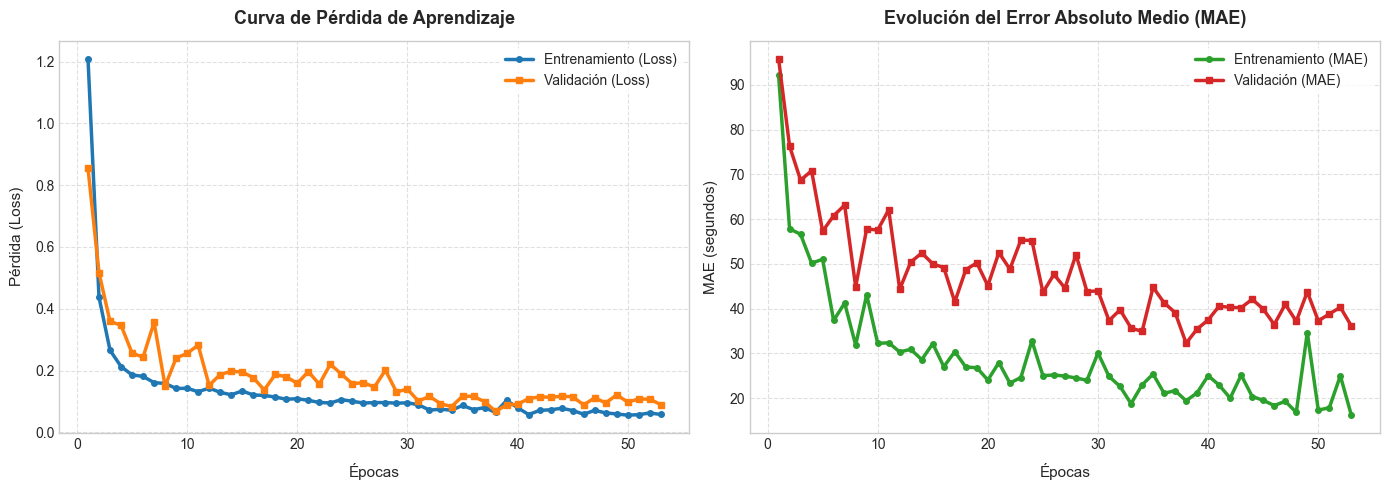

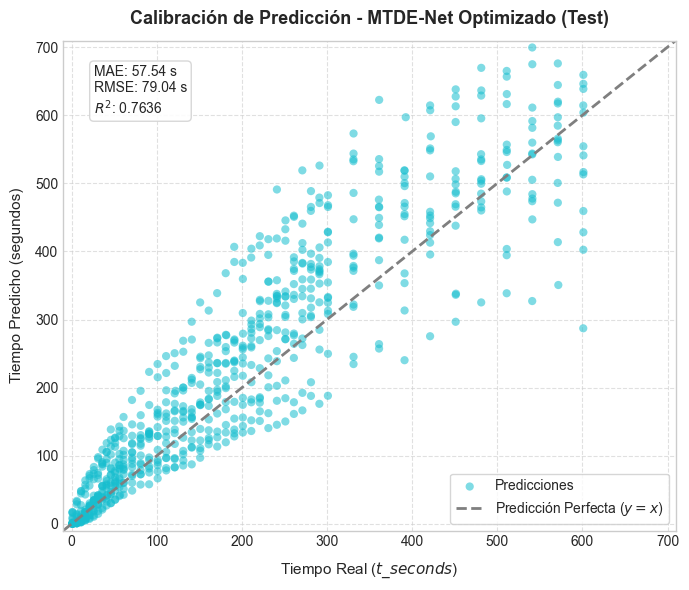

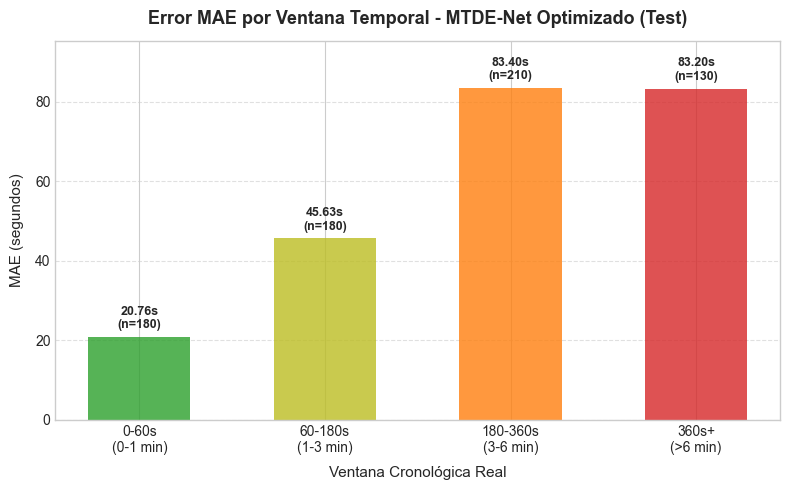

In [7]:
def average_histories(histories):
    max_epochs = max(len(h["train_loss"]) for h in histories)
    avg_hist = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    for epoch in range(max_epochs):
        for key in avg_hist.keys():
            vals = [h[key][epoch] for h in histories if epoch < len(h[key])]
            avg_hist[key].append(float(np.mean(vals)))
    return avg_hist

# 1. Graficar Curvas de Aprendizaje Promediadas (Folds de Validación CV)
print("Graficando curvas de aprendizaje promedio de la validación cruzada...")
plot_learning_curves(average_histories(histories_opt))

# 2. Obtener y_true e y_pred del Test Set para el modelo final optimizado
def get_predictions_and_targets(model, loader, device, scale=30.0):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for x_img, x_tab, y in loader:
            x_img, x_tab, y = x_img.to(device), x_tab.to(device), y.to(device)
            p = model(x_img, x_tab)
            all_preds.append(p.cpu().numpy() * scale)
            all_targets.append(y.cpu().numpy() * scale)
    return np.concatenate(all_targets).flatten(), np.concatenate(all_preds).flatten()

y_true_test, y_pred_test = get_predictions_and_targets(model_opt, test_loader, dev, scale=time_scale)

# 3. Gráfico de Calibración en el Test Set
plot_prediction_calibration(y_true_test, y_pred_test, model_name="MTDE-Net Optimizado (Test)")

# 4. Error por Ventanas Temporales en el Test Set
plot_error_by_time_window(y_true_test, y_pred_test, model_name="MTDE-Net Optimizado (Test)")